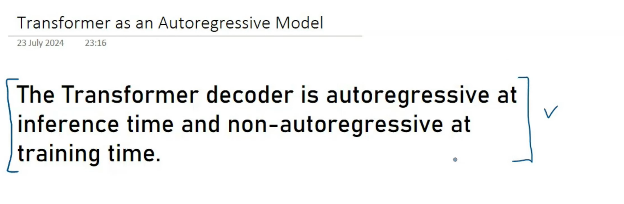

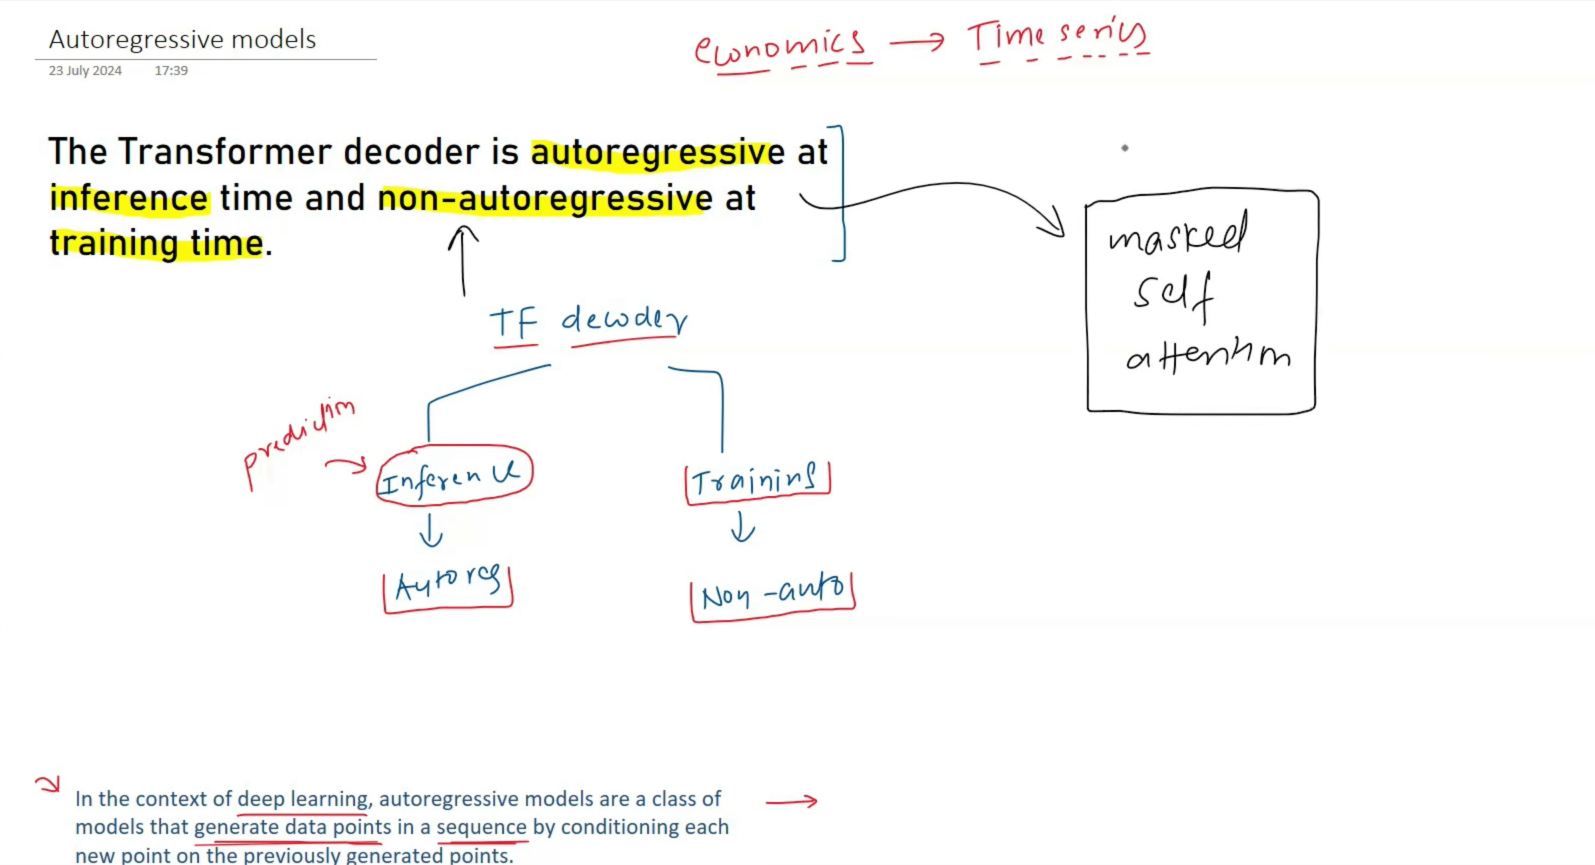

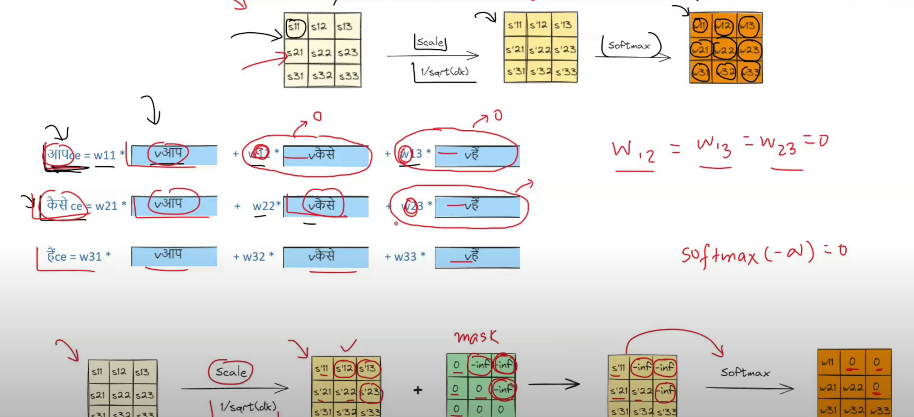

T

The core idea discussed in then be summarized by this sentence: **"The Transformer decoder is an auto-regressive model at inference time and non-auto-regressive at training time"**.

1.  **Understanding Auto-regressive and Non-auto-regressive:**
    *   **Inference** refers to the prediction stage of a model. An **auto-regressive model** generates data points in a sequence, where each new data point depends on the previously generated points. For example, in language translation, to predict the next word, the model needs to know the words it has already produced. This sequential generation is a necessity for understanding sequential data because future elements depend on past elements. Therefore, the Transformer decoder **must be auto-regressive during inference**.
    *   **Training** refers to the process of teaching the model. The Transformer decoder is **non-auto-regressive during training**. If training were also auto-regressive (sequential), it would be extremely slow, as each word in a long sentence would be processed one after another.

2.  **The Training Dilemma: Speed vs. Data Leakage:**
    *   To make training faster, a **non-auto-regressive (parallel) approach** is desired, where all words of the target sentence are processed simultaneously.
    *   However, a simple parallel approach introduces a problem called **data leakage**. This means that when the model is calculating the contextual meaning of a word, it accidentally "sees" future words in the sentence. This is like "cheating" because during real-world prediction (inference), the model won't have access to future words. This leads to good performance on training data but poor performance on new data.
    *   So, the dilemma is: **Auto-regressive training is slow but avoids data leakage, while non-auto-regressive (parallel) training is fast but causes data leakage**.

3.  **The Solution: Masked Self-Attention:**
    *   **Masked Self-Attention** solves this dilemma by allowing parallel processing during training while preventing data leakage.
    *   In the self-attention mechanism, words are converted into numerical representations (embeddings), which are then used to calculate "query," "key," and "value" vectors. These are used to determine **attention scores**, which show how much each word should pay attention to other words.
    *   To prevent data leakage, a **mask** is applied. After the attention scores are calculated and scaled, a matrix with **negative infinity (`-inf`)** values is added to the attention scores at the positions of future words.
    *   When the **softmax function** (which converts scores into probabilities) is applied to these scores, any `-inf` value becomes **zero**.
    *   This effectively means that a word's contextual embedding cannot use information from words that appear later in the sequence, even though all words are processed in parallel.

This masking technique allows the Transformer decoder to achieve **the best of both worlds**: it can train quickly using parallel processing (non-auto-regressive) while still ensuring that current words do not illegally access information from future words, which is essential for accurate predictions during inference (auto-regressive behavior).



### Understanding the Transformer Architecture and its Decoder

*   **What is the Transformer architecture, and why is it important in AI?**
    *   The Transformer architecture is a crucial framework that **drives most of the advancements** currently seen in the field of AI. It is considered a highly important topic.
*   **What are the two main parts of the Transformer architecture?**
    *   The Transformer architecture can be divided into two primary components: an **Encoder** and a **Decoder**.
*   **What is the current focus of discussion regarding the Transformer?**
    *   The discussion is focused on the **Decoder architecture**, specifically exploring its complex parts.
*   **Are all parts of the Decoder entirely new compared to the Encoder?**
    *   **No**, many elements from the Encoder are repeated in the Decoder, such as Multi-head Attention, Positional Encoding, Add & Norm layers, and Feed Forward layers.
*   **What are the key *new* building blocks introduced in the Decoder that need to be understood?**
    *   The two major new building blocks are **Masked Self-Attention** (or Masked Multi-head Attention) and **Cross-Attention**. The current discussion is fully dedicated to understanding Masked Multi-head Attention.

### The Core Principle: Auto-regressive vs. Non-auto-regressive Behavior

*   **What is the fundamental statement summarizing the Transformer Decoder's behavior?**
    *   The Transformer decoder is an **auto-regressive model at inference time and non-auto-regressive at training time**.
*   **What does "Inference" mean in this context?**
    *   **Inference** simply means **prediction**. When the Transformer is used to make predictions, its decoder behaves auto-regressively.
*   **What does "Training" mean in this context?**
    *   **Training** refers to the process where the model learns from data. During this phase, the decoder behaves non-auto-regressively.
*   **What is an "auto-regressive model" in Deep Learning?**
    *   Auto-regressive models are a class of models that **generate data points in a sequence by conditioning each new data point on the previously generated points**. For example, in stock prediction, Friday's stock value prediction depends on Thursday's and Wednesday's values. In language translation, to generate the current word, the model needs to know the words it has already produced.
*   **Why do models handling sequential data (like language translation or text generation) *need* to be auto-regressive during generation (inference)?**
    *   Because **sequential data inherently requires that future elements depend on past elements**. You cannot generate an entire sentence or paragraph at once, as the meaning and choice of later words are influenced by earlier words. It's a fundamental aspect of such data, leaving no other option for generation. Therefore, being auto-regressive during inference is a **compulsion**.

### The Training Dilemma: Speed vs. Data Leakage

*   **What is the desired behavior for the Decoder during training, and why?**
    *   During training, it is highly desirable for the Decoder to be **non-auto-regressive**, meaning it processes all words of the target sentence **in parallel**. This is because parallel processing **significantly speeds up the training process**.
*   **What is the "problem" if the Decoder is designed to be *auto-regressive* during training?**
    *   The primary problem is that training becomes **extremely slow**. For a sentence with, say, three words, the decoder's internal operations would run four times (including a start token). For a paragraph of 300 words, it would run 301 times, making it computationally very expensive, especially with large datasets.
*   **If auto-regressive training is slow, why not just process everything in parallel (non-auto-regressively) without any special adjustments?**
    *   Processing all words in parallel during training without adjustments introduces a critical "problem" known as **data leakage**.
*   **What is "data leakage" in the context of parallel training for the Decoder?**
    *   Data leakage occurs when, during training, the model **accidentally "sees" or uses information from future tokens** (words) in the target sequence when calculating the contextual meaning of a current token. For example, if the model is trying to understand "आप" (you), it might use information from "कैसे" (how) and "हैं" (are), even though "कैसे" and "हैं" would not yet exist during real-world inference.
*   **Why is data leakage a "problem"?**
    *   It's considered **"cheating"**. If the model is exposed to future information during training, it will perform well on the training data but **poorly on real-world data** during prediction (inference) because that future information will not be available.
*   **What is the overall "dilemma" facing the Transformer Decoder during training?**
    *   The dilemma is that auto-regressive training avoids data leakage but is very slow, while parallel (non-auto-regressive) training is fast but causes data leakage. The challenge is how to get the **"best of both worlds"**: fast training *without* data leakage.

### The Solution: Masked Self-Attention

*   **What is the "solution" to the dilemma of fast training without data leakage?**
    *   The solution lies in **Masked Self-Attention**.
*   **How does the Self-Attention mechanism generally work, providing context for the mask?**
    *   Words are first converted into **embeddings**.
    *   These embeddings are then transformed into **Query (Q), Key (K), and Value (V) vectors** using weight matrices (Wq, Wk, Wv).
    *   **Attention scores** are calculated by taking the dot product of the Query matrix with the transpose of the Key matrix (Q * K^T).
    *   These scores are then **scaled**.
    *   Finally, a **softmax function** is applied to these scaled scores, resulting in weights that determine how much attention each word pays to others.
    *   The contextual embeddings for each word are then calculated by multiplying these weights with the Value vectors.
*   **What specifically "needs" to be prevented within the Self-Attention calculation to avoid data leakage during parallel training?**
    *   When calculating the contextual embedding for any given word, the contributions from **all subsequent (future) words** in the sequence must be effectively **zeroed out**.
*   **How does Masked Self-Attention achieve this "zeroing out" of future information?**
    *   After the attention scores are calculated and scaled, a **mask matrix** of the exact same dimensions is created.
    *   At the positions in this mask matrix corresponding to where a word *would* attend to a future word, **minus infinity (`-inf`) values are placed**. Other positions have zeros.
    *   This mask matrix is then **added** to the scaled attention scores. This turns the scores for future words into `-inf`.
    *   When the **Softmax function** is applied to these modified scores, any `-inf` value gets converted into **zero**.
    *   These zero values effectively act as **weights of zero** for future words, preventing them from contributing to the contextual embedding of the current word.
*   **What is the "outcome" or "benefit" of implementing Masked Self-Attention?**
    *   Masked Self-Attention allows the Transformer decoder to achieve the **"best of both worlds"**.
    *   It enables **parallel processing** during training, making it fast and efficient.
    *   At the same time, it **prevents data leakage** by ensuring that current tokens do not gain information from future tokens, thus maintaining the auto-regressive nature required for accurate prediction. This means training can be non-auto-regressive while still behaving correctly.



---

# 🔹 1. Self-Attention Recap

Self-attention lets each token in a sequence look at (attend to) other tokens to build contextualized representations.

For a sequence of tokens $X \in \mathbb{R}^{n \times d_{model}}$:

* Compute **queries, keys, values**:

$$
Q = XW^Q, \quad K = XW^K, \quad V = XW^V
$$

where $W^Q, W^K, W^V \in \mathbb{R}^{d_{model} \times d_k}$.

* Attention weights:

$$
\text{Scores} = \frac{QK^T}{\sqrt{d_k}}
$$

* Attention output:

$$
\text{Attention}(Q,K,V) = \text{softmax}(\text{Scores}) \, V
$$

---

# 🔹 2. Masked Self-Attention (Intuition)

In **language modeling** (e.g., GPT), when predicting the next word at position $t$,
the model **must not peek at future tokens** ($t+1, t+2, \dots$).

👉 Masked self-attention enforces this by applying a **causal mask** (triangular matrix).

### Example:

For a sequence of length $n=5$, the mask is:

$$
M =
\begin{bmatrix}
0 & -\infty & -\infty & -\infty & -\infty \\
0 & 0 & -\infty & -\infty & -\infty \\
0 & 0 & 0 & -\infty & -\infty \\
0 & 0 & 0 & 0 & -\infty \\
0 & 0 & 0 & 0 & 0
\end{bmatrix}
$$

Each row corresponds to a query position; it can only see itself and past tokens.

---

# 🔹 3. Masked Self-Attention (Math)

We modify the scores before softmax:

$$
\text{Scores}_{masked} = \frac{QK^T}{\sqrt{d_k}} + M
$$

where:

* $M_{ij} = 0$ if $j \leq i$ (allowed),
* $M_{ij} = -\infty$ if $j > i$ (forbidden).

Then:

$$
\text{MaskedAttention}(Q,K,V) = \text{softmax}(\text{Scores}_{masked}) V
$$

The $-\infty$ ensures that future positions contribute **zero weight** after softmax.

---

# 🔹 4. Multi-Head Attention

Instead of one attention mechanism, Transformers use multiple “heads” that look at different subspaces of the embeddings.

For **h heads**:

* Each head has its own $W^Q_i, W^K_i, W^V_i$.
* Compute attention separately:

$$
\text{head}_i = \text{MaskedAttention}(QW^Q_i, KW^K_i, VW^V_i)
$$

* Concatenate heads:

$$
\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O
$$

---

# 🔹 5. Intuition: Why Masked Multi-Head Attention?

* **Multi-head**: Different heads learn different types of dependencies (e.g., syntax, long-range context).
* **Masking**: Ensures autoregressive property (no cheating).
* Combined, the model can **learn diverse contextual dependencies from only the past**.

---

# 🔹 6. Visual Intuition

* **Unmasked attention (BERT)**:
  Each word can attend to *all* words in the sentence.

* **Masked attention (GPT)**:
  Word at position $t$ can only attend to words $\leq t$.
  This makes it usable for **generating text** step by step.

---

✅ **Summary**

* Self-attention = $ \text{softmax}(QK^T / \sqrt{d_k}) V$
* Masking = add triangular mask before softmax
* Multi-head = multiple parallel attention computations
* Masked multi-head attention = allows autoregressive training for text generation.

---





---

## 🔹 Interview Q\&A

### Q1. What is self-attention in Transformers?

**A:**
Self-attention computes a weighted sum of all tokens in a sequence, where the weights represent how much each token attends to others.
Mathematically:

$$
\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

This allows each token’s representation to be contextualized by the entire sequence.

---

### Q2. What is masked self-attention and why is it needed?

**A:**

* Masked self-attention prevents a token from attending to future tokens.
* This is essential in **autoregressive tasks** (e.g., GPT text generation), where predicting token $t$ must not use information from tokens $t+1, t+2, \dots$.
* Implemented via a **causal mask** (upper-triangular matrix of $-\infty$) added to the attention scores before softmax.

---

### Q3. How is the masking applied mathematically?

**A:**

$$
\text{Scores}_{masked} = \frac{QK^T}{\sqrt{d_k}} + M
$$

where $M_{ij} = 0$ if $j \leq i$, and $M_{ij} = -\infty$ if $j > i$.
After applying softmax:

$$
\text{MaskedAttention}(Q,K,V) = \text{softmax}(\text{Scores}_{masked}) V
$$

This ensures all probabilities for future tokens become zero.

---

### Q4. What is the difference between masked and unmasked self-attention?

**A:**

* **Unmasked (BERT, encoder):** Each token can attend to all tokens (bidirectional context).
* **Masked (GPT, decoder):** Each token can only attend to past and current tokens (causal, autoregressive).

---

### Q5. What is multi-head attention and why is masking still needed there?

**A:**

* Multi-head attention uses multiple parallel attention layers (heads), each learning different types of dependencies.
* Formula:

$$
\text{head}_i = \text{MaskedAttention}(QW^Q_i, KW^K_i, VW^V_i)
$$

$$
\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O
$$

* Masking is applied within **each head** to preserve the autoregressive property.

---

### Q6. Can you give an intuition for why masking is critical in generation?

**A:**
Without masking, the model would “cheat” during training by seeing future words. Then at inference, when generating one token at a time, it would fail because it no longer has access to those future tokens.

---

### Q7. What happens if you forget to apply the mask?

**A:**

* The model will leak future information during training.
* It might achieve artificially low loss but won’t generalize properly for generation.
* Generated text could collapse or repeat nonsensically.

---

### Q8. Which Transformer components use masking?

**A:**

* **Encoder self-attention (BERT):** No mask.
* **Decoder self-attention (GPT):** Uses causal mask.
* **Encoder-decoder cross-attention (in seq2seq models):** No mask (decoder queries attend to all encoder outputs).

---




---

# 🔹 1. What does *autoregressive* mean?

* **Autoregressive modeling** = Predict the next token conditioned on **all previous tokens**.

$$
P(x) = \prod_{t=1}^{T} P(x_t \mid x_1, \dots, x_{t-1})
$$

* At each step, the model only has access to the tokens **up to position $t-1$** (causal dependency).

* In Transformers, this is implemented using **masked self-attention** so a token cannot peek at the future.

👉 Example: GPT is an **autoregressive decoder-only Transformer**.

---

# 🔹 2. What is *teacher forcing*?

* **Teacher forcing** is a training strategy for sequence-to-sequence models:

  * During training, when predicting token $t$, the model is fed the **ground-truth token** $x_{t-1}$ as input.
  * During inference, the model uses its **own predicted tokens** autoregressively.

* Why?

  * Makes training stable and faster (the model sees the correct past sequence).
  * But at inference, the model must “generate” step by step, which can expose it to compounding errors (this gap is called **exposure bias**).

---

# 🔹 3. Encoder–Decoder Transformers (e.g., Seq2Seq like T5, original Transformer for translation)

* **Encoder:**

  * Reads the full source sequence.
  * Uses **unmasked self-attention** (can see all positions).
  * Outputs contextualized representations.

* **Decoder:**

  * Uses **masked self-attention** (autoregressive).
  * During training:

    * Teacher forcing is applied → decoder input is the *ground-truth shifted right* sequence.
  * During inference:

    * Autoregressive generation → decoder generates one token at a time, feeds it back as input.

* **Cross-attention:** Decoder queries attend to the encoder outputs (no masking here).

---

# 🔹 4. Decoder-only Transformers (GPT style)

* No encoder.
* Entire model is autoregressive with **masked self-attention**.
* Training: Teacher forcing is still used (shifted input vs. output).

  * Input: $[x_1, x_2, \dots, x_{T-1}]$
  * Target: $[x_2, x_3, \dots, x_T]$
* Inference: Generate token by token.

---

# 🔹 5. Intuition Difference

* **Autoregressive**: How the model *formulates probability* (condition on past only).
* **Teacher forcing**: A *training trick* to make learning stable by using ground-truth tokens instead of the model’s own predictions.

So:

* Autoregression = property of the architecture (causal mask).
* Teacher forcing = training method for autoregressive decoders.

---

# 🔹 6. Example

Suppose target sentence: `"I love NLP"`

* Training (teacher forcing):

  * Input to decoder: `["<BOS>", "I", "love"]`
  * Target: `["I", "love", "NLP"]`

* Inference (autoregressive):

  * Step 1: Input `<BOS>` → predicts `"I"`
  * Step 2: Input `<BOS>, I` → predicts `"love"`
  * Step 3: Input `<BOS>, I, love` → predicts `"NLP"`

---

✅ **Summary for interview**:

* **Autoregressive** = predict next token conditioned on past tokens only (causal mask in Transformers).
* **Teacher forcing** = during training, feed the ground-truth previous token instead of the model’s predicted token to stabilize learning.
* In **encoder–decoder Transformers**, the encoder sees all input, while the decoder is autoregressive + teacher forcing.
* In **decoder-only Transformers**, the whole model is autoregressive and trained with teacher forcing.

---


